# Task 1 - Financial AI: LLM-Powered Equity Research Assistant

Run each cell top to bottom in Google Colab. Requires a Mistral AI API key
(stored as a Colab secret or environment variable `MISTRAL_API_KEY`) --
**never hardcode it in this notebook.**


In [1]:
!pip install -q yfinance mistralai pydantic matplotlib pandas numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 8.4 MB/s eta 0:00:00


In [2]:
import os
from google.colab import userdata
# Store your key via Colab's Secrets panel (key icon in the left sidebar),
# name it MISTRAL_API_KEY. This keeps it out of the notebook file entirely.
os.environ['MISTRAL_API_KEY'] = userdata.get('MISTRAL_API_KEY')


In [3]:
import os
import sys

# Dynamically locate the directory containing 'data_pipeline.py' from current workspace
for root, dirs, files in os.walk('/'):
    if 'data_pipeline.py' in files:
        if root not in sys.path:
            sys.path.insert(0, root)
        break

from data_pipeline import run_pipeline
from llm_reasoning import _get_client, classify_all_headlines, generate_trade_signal
from report_renderer import render_report

TICKER = 'AAPL'

## Task 1A - Data Pipeline

In [4]:
result = run_pipeline(TICKER)
summary = result['summary']
ohlcv = result['ohlcv']
news = result['news']

print(summary)
print(f"\nRetrieved {len(news)} headlines")
ohlcv.tail()

TickerSnapshot(ticker='AAPL', current_price=326.57000732421875, fifty_two_week_high=340.0799865722656, fifty_two_week_low=226.7899932861328, pe_ratio=38.29014, ytd_return_pct=20.50108688112413, momentum_signal='bullish', data_warnings=[])

Retrieved 10 headlines


Price,Adj Close,Close,High,Low,Open,Volume,SMA_50,SMA_200,RSI_14,MACD,MACD_signal,MACD_hist,BB_mid,BB_upper,BB_lower,BB_percent_b
Date,,,,,,,,,,,,,,,,
2026-09-03,328.209991,328.209991,330.809998,324.109985,324.869995,37225800,314.254999,283.607499,63.384194,2.672223,0.644389,2.027834,312.807999,327.006393,298.609605,1.042385
2026-09-04,319.970001,319.970001,328.929993,317.859985,328.309998,39606900,315.151400,283.870049,53.886211,2.592430,1.033997,1.558433,313.139999,327.678151,298.601848,0.734899
2026-09-08,316.220001,316.220001,320.700012,314.899994,317.100006,35477100,315.800200,284.113949,50.199500,2.201225,1.267443,0.933782,313.537999,327.955303,299.120695,0.593013
2026-09-09,315.339996,315.339996,319.149994,309.899994,315.489990,65640000,316.472200,284.347849,49.346293,1.799441,1.373842,0.425598,314.059499,327.935081,300.183916,0.546142
2026-09-10,326.570007,326.570007,326.739990,316.510010,316.670013,69925100,317.216400,284.649449,58.937625,2.359988,1.571071,0.788916,315.275499,329.060523,301.490475,0.909666


## Task 1B - LLM Sentiment and Signal Reasoning

In [5]:
client = _get_client()
headline_sentiments, agg_sentiment = classify_all_headlines(client, news)

for h in headline_sentiments:
    print(f"[{h.sentiment:>8}] conf={h.confidence:.2f}  {h.headline}")
print('\nAggregate:', agg_sentiment)

ERROR:llm_reasoning:Giving up on headline after 2 attempts: What a Republican 'wipeout' in the midterm elections means for investors
ERROR:llm_reasoning:Giving up on headline after 2 attempts: Why hardware will attract buyers to Apple's new lineup over AI features
ERROR:llm_reasoning:Giving up on headline after 2 attempts: The Next Growth Cycle Could Take Qualcomm to New Highs
ERROR:llm_reasoning:Giving up on headline after 2 attempts: Stop Wasting Money: How to Find and Cancel Unused Subscriptions in 15 Minutes or Less
ERROR:llm_reasoning:Giving up on headline after 2 attempts: Samsung Gets $250 For Every iPhone Duo You Buy
ERROR:llm_reasoning:Giving up on headline after 2 attempts: Fed Rate Hike Close To A Lock; Clarity Act Vote Looms: Week Ahead
ERROR:llm_reasoning:Giving up on headline after 2 attempts: Apple Advances 3% as First Foldable iPhone Arrives at Its Highest Price Ever; Skyworks Rallies 9%, Alphabet Ticks Up
ERROR:llm_reasoning:Giving up on headline after 2 attempts: Stoc


Aggregate: overall_score=0.0 positive_count=0 negative_count=0 neutral_count=0 total_headlines=0


In [6]:
latest = ohlcv.iloc[-1].to_dict()
latest['fifty_two_week_high'] = summary.fifty_two_week_high
latest['fifty_two_week_low'] = summary.fifty_two_week_low
latest['ytd_return_pct'] = summary.ytd_return_pct

trade_signal = generate_trade_signal(client, TICKER, latest, agg_sentiment)
print(trade_signal)

ERROR:llm_reasoning:Giving up on trade signal generation after 2 attempts


None


## Bonus - Rendered HTML Research Brief


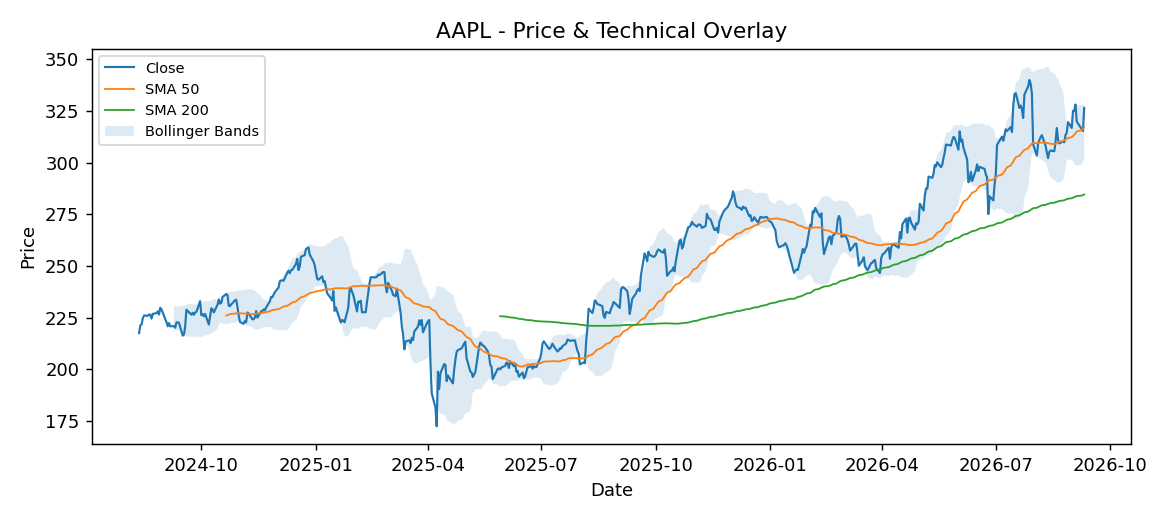

In [7]:
html = render_report(TICKER, summary, headline_sentiments, agg_sentiment, trade_signal, ohlcv)
with open(f'{TICKER}_research_brief.html', 'w') as f:
    f.write(html)

from IPython.display import HTML, display
display(HTML(html))